<a href="https://colab.research.google.com/github/lariscardoz4/project/blob/main/Linear_Regression_California_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

In [13]:
data = fetch_california_housing(as_frame=True).frame
print("rows, columns:", data.shape)
data.head()

rows, columns: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [72]:
X = data[["MedInc"]] # Select 'MedInc' as a DataFrame (2D) instead of a Series (1D)
y = data["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Learn from", X_train.shape[0], "examples")
print("Test on", X_test.shape[0], "examples")

Learn from 16512 examples
Test on 4128 examples


In [73]:
model = LinearRegression()
model.fit(X_train, y_train)
print("slope :", round(model.coef_[0], 3))
print("start :", round(model.intercept_, 3))

slope : 0.419
start : 0.445


In [74]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 3))
print("MSE:", round(mse, 3))
print("MAE:", round(mae, 3), " (off by about $" + format(round(mae * 100000), ",") + " on average)")
print("R2 :", round(r2, 3), " (share of the variation explained)")

MAE: 0.63
MSE: 0.709
MAE: 0.63  (off by about $62,991 on average)
R2 : 0.459  (share of the variation explained)


When we perform the linear regression model on a median house value based on the median income we get to know that the prediction differs from the actual median house value by approximately $62,991


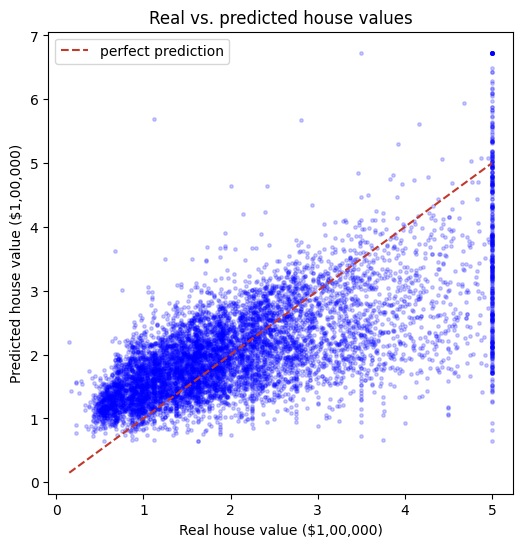

In [64]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, s=6, alpha=0.2, color="Blue", marker='o')
lo, hi = y_test.min(), y_test.max()
plt.plot([lo, hi], [lo, hi], "--", color="#C0392B", label="perfect prediction")
plt.xlabel("Real house value ($1,00,000)")
plt.ylabel("Predicted house value ($1,00,000)")
plt.title("Real vs. predicted house values")
plt.legend()
plt.show()

1. Change test_size in Step 2 from 0.2 to 0.4 and re-run Steps 2-4. Do the scores move much?

In [75]:
X = data[["MedInc"]]
y = data["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=0)

print("learn from :", X_train.shape[0], "districts")
print("judge on   :", X_test.shape[0], "hidden districts")

learn from : 12384 districts
judge on   : 8256 hidden districts


In [76]:
model = LinearRegression().fit(X_train, y_train)

print("slope :", round(model.coef_[0], 3))
print("start :", round(model.intercept_, 3))

slope : 0.422
start : 0.439


In [77]:
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", round(mae, 3), " (off by about $" + format(round(mae * 100000), ",") + " on average)")
print("R2 :", round(r2, 3), " (share of the variation explained)")

MAE: 0.628  (off by about $62,845 on average)
R2 : 0.465  (share of the variation explained)


If we change the test size from 0.2 to 0.4 the test score does not move much...
MAE: 0.629
MSE: 0.709
MAE: 0.629  (off by about $62,870 on average)
R2 : 0.471  (share of the variation explained)

2. In Step 2, swap the single feature "MedInc" for "HouseAge" and re-run. Is age a better or worse single predictor? Look at the R².


In [78]:
# swapping median income to houseage
X = data[["HouseAge"]]
y = data["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0)

print("learn from :", X_train.shape[0], "districts")
print("judge on   :", X_test.shape[0], "hidden districts")

learn from : 16512 districts
judge on   : 4128 hidden districts


In [79]:
model = LinearRegression().fit(X_train, y_train)

print("slope :", round(model.coef_[0], 3))
print("start :", round(model.intercept_, 3))


slope : 0.01
start : 1.793


In [80]:
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", round(mae, 3), " (off by about $" + format(round(mae * 100000), ",") + " on average)")
print("R2 :", round(r2, 3), " (share of the variation explained)")

MAE: 0.901  (off by about $90,149 on average)
R2 : 0.01  (share of the variation explained)


 Is age a better or worse single predictor? Look at the R².
 Ans: MedInc is significantly better single predictor as higher R-squared value indicates a better fit.


3. "on average, how many dollars is our one-feature model off by?"
Ans: answer?
When using 'HouseAge' as the single feature, our model is off by approximately **$90,149** on average. This is indicated by the MAE value of `0.901` (which, when scaled by 100,000, becomes $$90,149** on average.